This notebook walks through the exploratory data analysis for Lumora Commerce's Customer Lifetime Value project. Before building any model, the goal here is simple: understand the data well enough that nothing surprises us later. That means looking at the shape of the transaction history, spotting any quality issues early, understanding how customers behave over time, and getting a feel for the revenue distribution before we start engineering features. Everything in this EDA feeds directly into the modelling decisions we'll make next.

In [1]:
# Import libraries
import requests, zipfile, io
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### **Data Collection**

In [2]:
# Extract the dataset
url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
  print(z.namelist())
  z.extractall("/content/")

['online_retail_II.xlsx']


In [3]:
df = pd.read_excel('online_retail_II.xlsx')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


In [5]:
print("Shape:", df.shape)
print("Columns names:", df.columns.to_list())
print("Data types:", df.dtypes)

Shape: (525461, 8)
Columns names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Data types: Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6865


In [7]:
print("Missing rows per columns:")
missing_columns = df.isnull().sum()
missing_columns

Missing rows per columns:


,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [8]:
# Percentage of missing rows per column
missing_pct = (missing_columns / len(df)) * 100
print("Percentage of missing rows per column:")
print(missing_pct)

Percentage of missing rows per column:
Invoice         0.000000
StockCode       0.000000
Description     0.557225
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    20.539488
Country         0.000000
dtype: float64


In [9]:
# Negative quantities (returns)
neg_qty = df[df["Quantity"] < 0]
print("Total returns:", len(neg_qty))

Total returns: 12326


In [10]:
# Negative unit prices
neg_prices = df[df["Price"] <= 0]
print("No of negative prices:", len(neg_prices))

No of negative prices: 3690


In [11]:
# Missing customerID
missing_customerID = df[df["Customer ID"].isnull()]
print("Missing CustomerID:", len(missing_customerID))

Missing CustomerID: 107927


In [12]:
# Cancelled orders
print("No of cancelled orders:", df["Invoice"].str.startswith("C").sum())

No of cancelled orders: 10206


The dataset has 525,461 rows and 8 columns. Most of the data types are fine already. InvoiceDate is already datetime, though Customer ID came in as float64 so we'll cast it to integer. Duplicates should be removed and rows with missing Customer IDs (about 20% of the data, no customer ID means no LTV analysis), and also filter out anything with a price of zero or below. Cancellations and returns are still in the data for now. we'll look at those properly during the EDA.

### **Data Cleaning**

In [13]:
eda_df = df.copy()
eda_df = eda_df.drop_duplicates()
eda_df = eda_df.dropna(subset=["Customer ID"])
eda_df = eda_df[eda_df["Price"] > 0]
eda_df["Customer ID"] = eda_df["Customer ID"].astype(int)
eda_df["Revenue"] = eda_df["Price"] * eda_df["Quantity"]
print(eda_df.head())


  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  Revenue  
0 2009-12-01 07:45:00   6.95        13085  United Kingdom     83.4  
1 2009-12-01 07:45:00   6.75        13085  United Kingdom     81.0  
2 2009-12-01 07:45:00   6.75        13085  United Kingdom     81.0  
3 2009-12-01 07:45:00   2.10        13085  United Kingdom    100.8  
4 2009-12-01 07:45:00   1.25        13085  United Kingdom     30.0  


In [14]:
eda_df.shape

(410732, 9)

After cleaning, we're left with 410,732 rows. This is our working dataset going forward.

### **Revenue And Sales Overview**

In [15]:
print("Total Revenue:", sum(eda_df["Revenue"]))

Total Revenue: 8314855.584


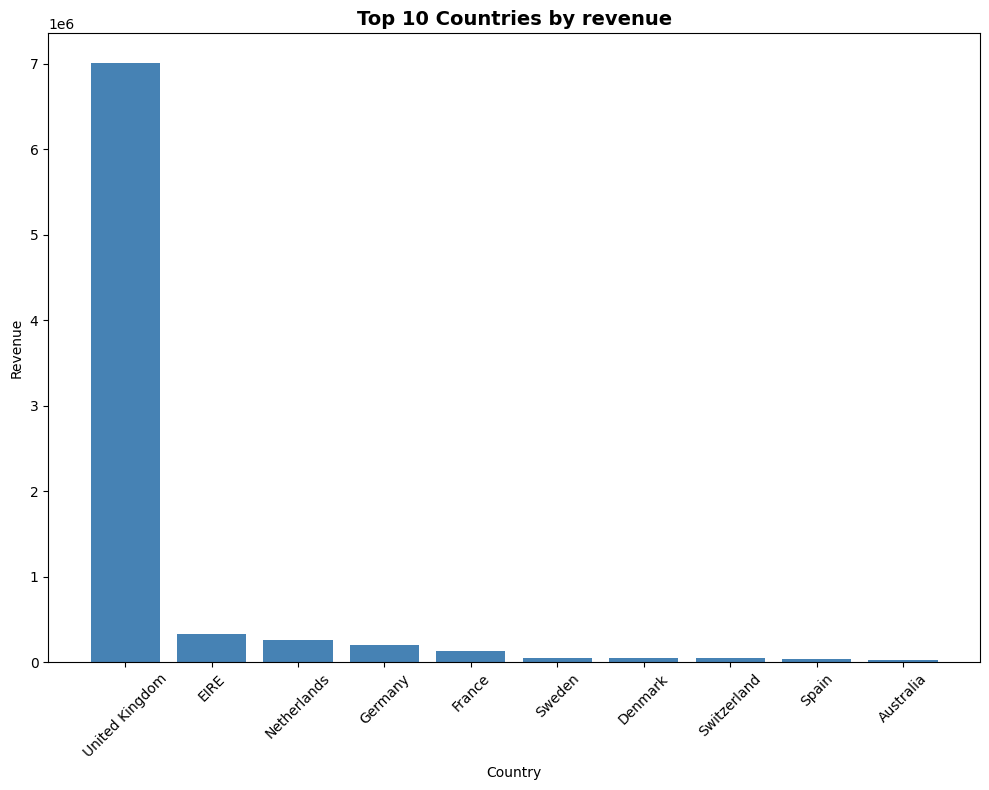

In [16]:
# Top 10 countries by revenue
top_10 = (eda_df.groupby("Country")["Revenue"]
          .sum()
          .nlargest(10)
          .reset_index())

plt.figure(figsize=(10,8))
plt.bar(top_10["Country"], top_10["Revenue"], color="steelblue")
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.title("Top 10 Countries by revenue", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
# Monthly revenue
eda_df["InvoiceDate"] = pd.to_datetime(eda_df["InvoiceDate"])
eda_df["YearMonth"] = eda_df["InvoiceDate"].dt.to_period("M")

monthly_revenue = eda_df.groupby("YearMonth")["Revenue"].sum().reset_index()
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)
monthly_revenue

,YearMonth,Revenue
0,2009-12,660125.100
1,2010-01,530436.512
2,2010-02,487596.426
3,2010-03,633419.311
4,2010-04,558007.832
5,2010-05,557873.390
6,2010-06,568784.550
7,2010-07,560885.330
8,2010-08,585259.460
9,2010-09,778520.051


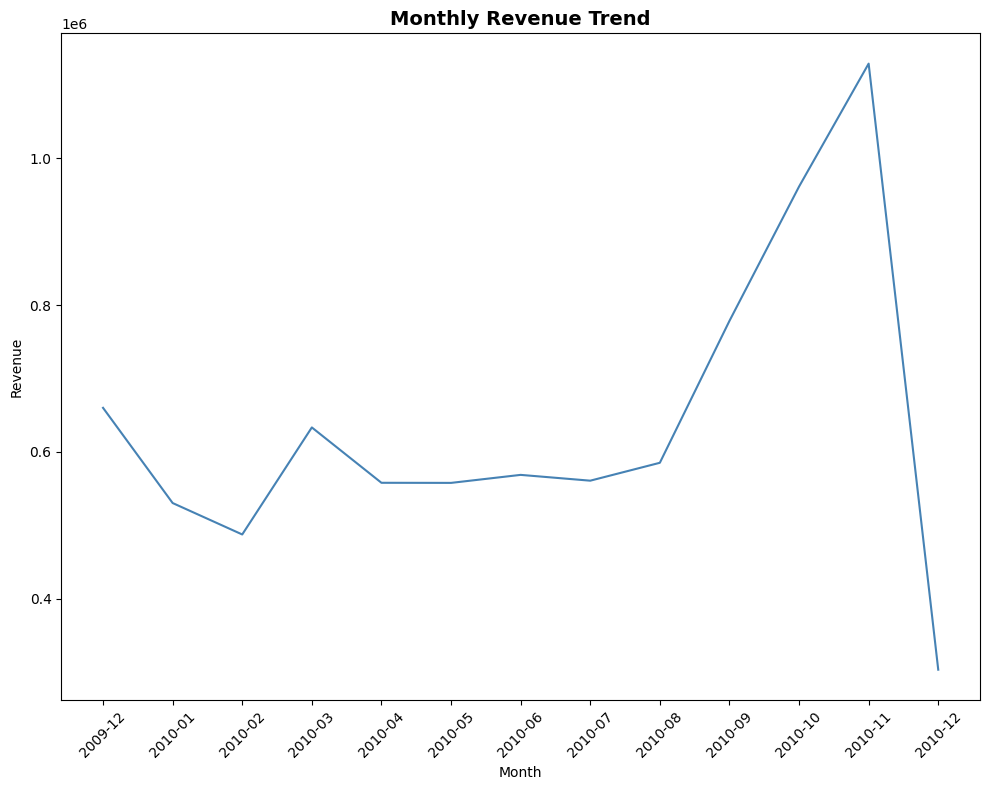

In [18]:
plt.figure(figsize=(10,8))
plt.plot(monthly_revenue["YearMonth"],
         monthly_revenue["Revenue"],
         color="steelblue")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

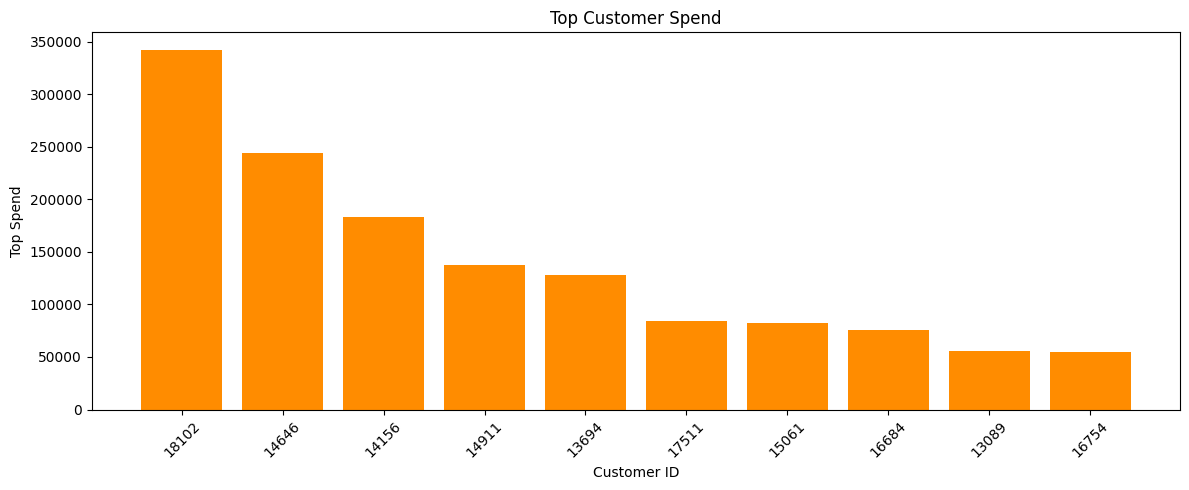

In [19]:
# Top 10 customer by spend
top_customers = (eda_df.groupby("Customer ID")["Revenue"]
                 .sum()
                 .nlargest(10)
                 .reset_index())
top_customers.columns = ["Customer ID", "Top Spend"]
top_customers["Customer ID"] = top_customers["Customer ID"].astype(str)

plt.figure(figsize=(12,5))
plt.bar(top_customers["Customer ID"], top_customers["Top Spend"], color="darkorange")
plt.xticks(rotation=45)
plt.xlabel("Customer ID")
plt.ylabel("Top Spend")
plt.title("Top Customer Spend")
plt.tight_layout()
plt.show()

In [20]:
# Total unique customer
total_customer = eda_df["Customer ID"].nunique()
print("Total unique customers:", total_customer)

Total unique customers: 4381


Total revenue across the dataset is £8.3 million. The UK dominates with about £7 million, which makes sense for a DTC brand operating primarily in that market. EIRE, Netherlands, and Germany follow but at a much smaller scale, so international sales exist but aren't the main story here.


Monthly revenue tells a pattern. The business picks up significantly from September through November 2010, peaking at £1.1 million in November. December drops sharply to £303k, but that's likely because the data cuts off mid-month, not an actual decline. The Q4 spike is classic e-commerce seasonality and something we'll want the model to account for.


We have 4,381 unique customers in total. Looking at the top spenders, the highest individual customer sits at £341k, which is a huge outlier. A handful of customers are clearly driving a disproportionate share of revenue, which is exactly the kind of pattern LTV segmentation is built to surface.

### **Customer Behaviour**

In [21]:
eda_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12


In [22]:
customer_stats = eda_df.groupby("Customer ID").agg(
                      Total_Orders = ("Invoice", "nunique"),
                      Total_spennd = ("Revenue", "sum"),
                      Avg_Order_Value = ("Revenue", "mean")
                   ).reset_index()
print(customer_stats)

      Customer ID  Total_Orders  Total_spennd  Avg_Order_Value
0           12346            15        -51.74        -1.149778
1           12347             2       1323.32        18.638310
2           12348             1        222.16        11.108000
3           12349             4       2646.99        24.738224
4           12351             1        300.93        14.330000
...           ...           ...           ...              ...
4376        18283             6        619.37         2.854240
4377        18284             2        436.68        15.057931
4378        18285             1        427.00        35.583333
4379        18286             3       1188.43        16.977571
4380        18287             5       2340.61        27.216395

[4381 rows x 4 columns]


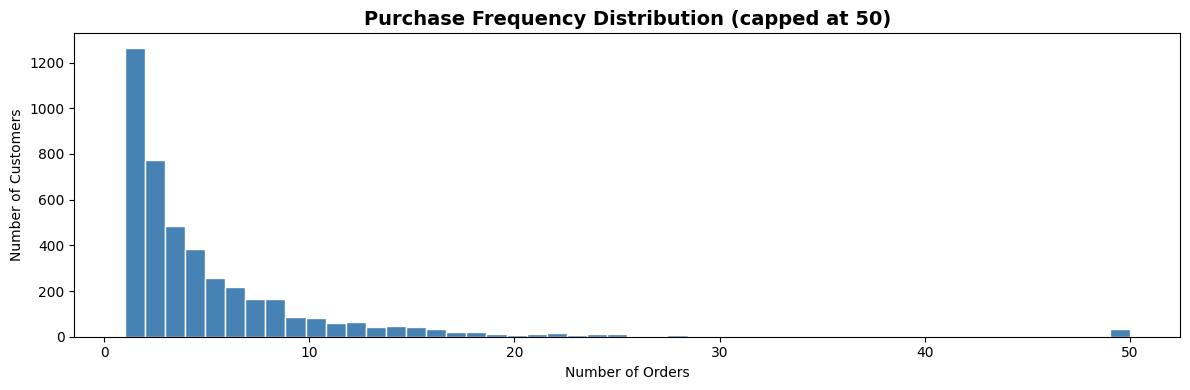

In [23]:
# Purchase distribution
plt.figure(figsize=(12,4))
plt.hist(customer_stats["Total_Orders"].clip(upper=50),
         bins=50,
         color="steelblue",
         edgecolor="white")
plt.title("Purchase Frequency Distribution (capped at 50)",
          fontweight="bold",
          fontsize=14)
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

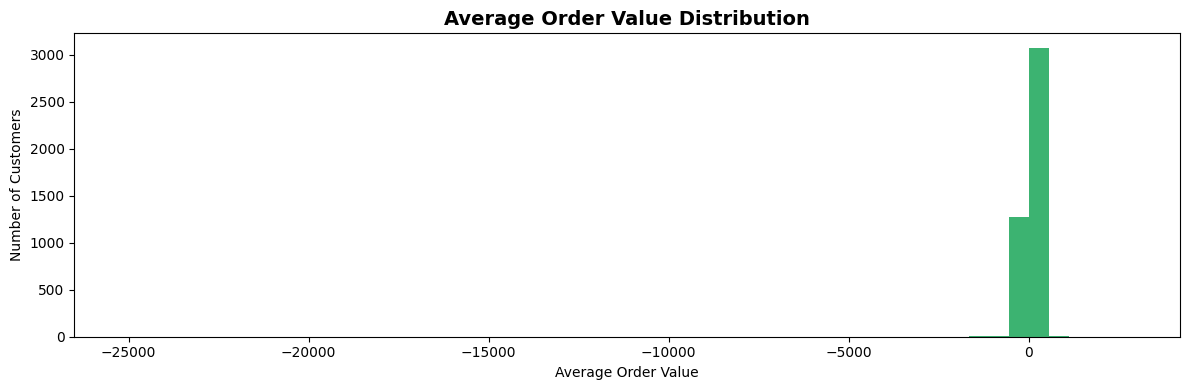

In [24]:
# Average order value distribution
plt.figure(figsize=(12,4))
plt.hist(customer_stats["Avg_Order_Value"], bins=50, color="mediumseagreen")
plt.title("Average Order Value Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Average Order Value")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [25]:
# One-time vs repeat buyers
one_time = (customer_stats["Total_Orders"] == 1).sum()
repeat = (customer_stats["Total_Orders"] > 1).sum()

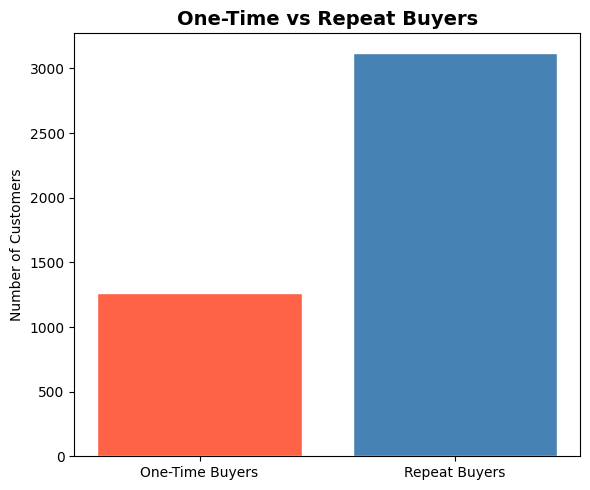

One-time buyers: 1265 (28.9%)
Repeat buyers: 3116 (71.1%)


In [26]:
plt.figure(figsize=(6, 5))
plt.bar(["One-Time Buyers", "Repeat Buyers"], [one_time, repeat],
        color=["tomato", "steelblue"], edgecolor="white")
plt.title("One-Time vs Repeat Buyers", fontsize=14, fontweight="bold")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print(f"One-time buyers: {one_time} ({one_time/len(customer_stats)*100:.1f}%)")
print(f"Repeat buyers: {repeat} ({repeat/len(customer_stats)*100:.1f}%)")

At the customer level, behaviour varies a lot. Some customers have placed 15 orders, others just one. Average order values range from a few pounds to well over £30, and you can already see a negative total spend for customer 12346 and that's a returns-heavy account and we'll flag later.


The one-time vs repeat split is encouraging. 71% of customers have bought more than once, which means the majority of the base is already showing some loyalty. The 29% who only bought once (1,265 customers) they are the ones worth watching. Some of them are just slow to return, others are gone for good, and the model will help us tell the difference.

### **Product Analysis**

In [27]:
eda_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12


In [28]:
# Top 20 products by quantity
top_products_qty = (eda_df.groupby(["Description"])["Quantity"]
                    .sum()
                    .sort_values(ascending=False)
                    .head(20)
                    .reset_index())
top_products_qty

,Description,Quantity
0,WHITE HANGING HEART T-LIGHT HOLDER,55760
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54130
2,BROCADE RING PURSE,47430
3,PACK OF 72 RETRO SPOT CAKE CASES,44480
4,ASSORTED COLOUR BIRD ORNAMENT,44000
5,60 TEATIME FAIRY CAKE CASES,35480
6,PACK OF 60 PINK PAISLEY CAKE CASES,30753
7,JUMBO BAG RED RETROSPOT,29439
8,BLACK AND WHITE PAISLEY FLOWER MUG,25679
9,SMALL POPCORN HOLDER,25379


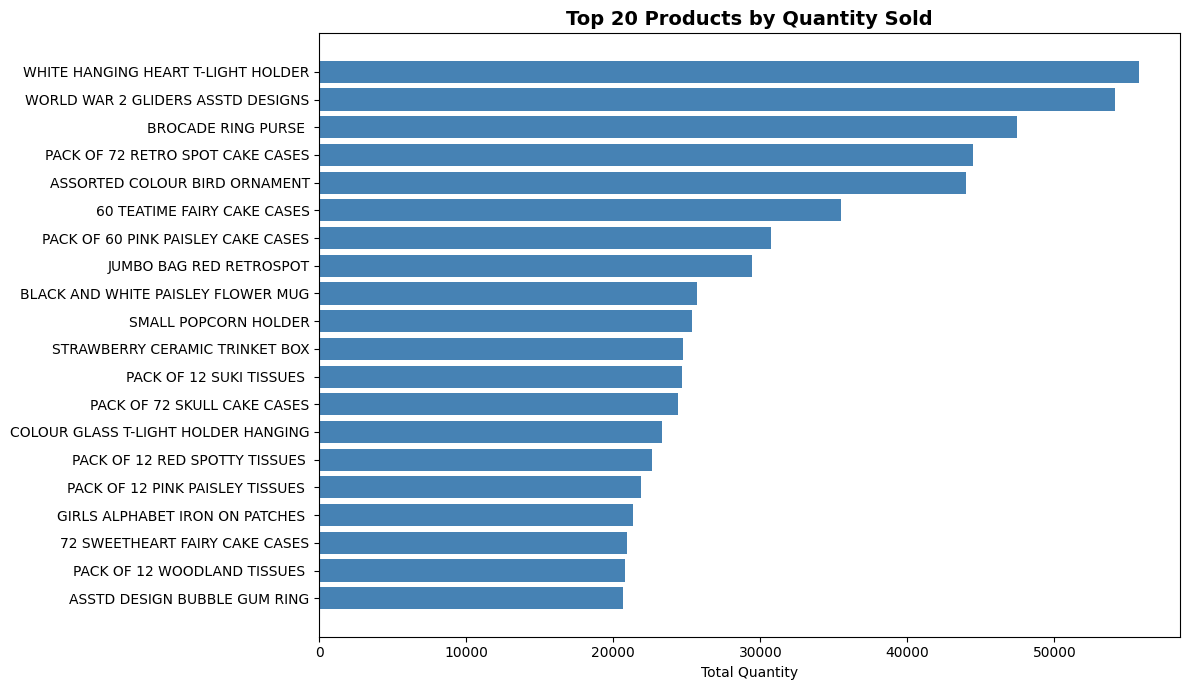

In [29]:
plt.figure(figsize=(12,7))
plt.barh(top_products_qty["Description"],
         top_products_qty["Quantity"],
         color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 20 Products by Quantity Sold", fontsize=14, fontweight="bold")
plt.xlabel("Total Quantity")
plt.tight_layout()
plt.show()

In [30]:
# Top 20 products by revenue
top_products_revenue = (eda_df.groupby("Description")["Revenue"]
                        .sum()
                        .sort_values(ascending=False)
                        .head(20)
                        .reset_index())
top_products_revenue

,Description,Revenue
0,WHITE HANGING HEART T-LIGHT HOLDER,148591.51
1,REGENCY CAKESTAND 3 TIER,136700.55
2,ASSORTED COLOUR BIRD ORNAMENT,69652.16
3,JUMBO BAG RED RETROSPOT,51493.35
4,POSTAGE,45520.86
5,ROTATING SILVER ANGELS T-LIGHT HLDR,39871.50
6,PAPER CHAIN KIT 50'S CHRISTMAS,36804.50
7,PARTY BUNTING,34980.10
8,JUMBO BAG STRAWBERRY,33862.50
9,EDWARDIAN PARASOL NATURAL,33541.65


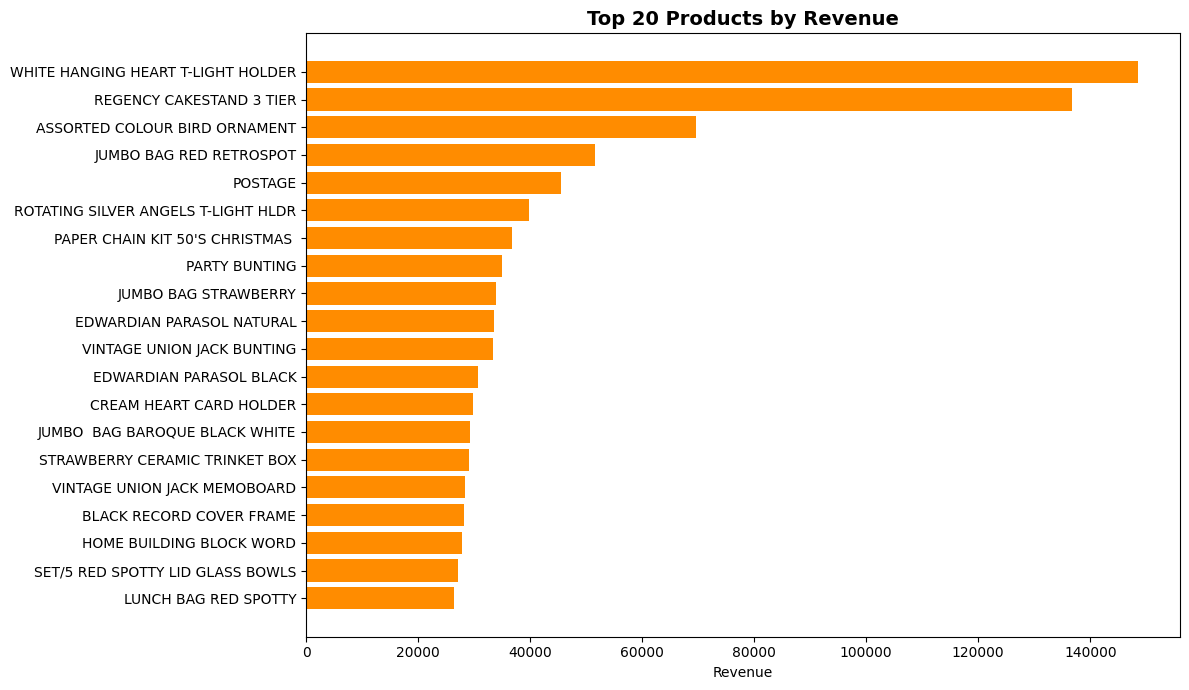

In [31]:
plt.figure(figsize=(12,7))
plt.barh(top_products_revenue["Description"],
         top_products_revenue["Revenue"],
         color="darkorange")
plt.gca().invert_yaxis()
plt.title("Top 20 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()


In [32]:
# Most returned products
returned_products_df = eda_df[eda_df["Quantity"] < 0].copy()
returned_products_df["ReturnQty"] = returned_products_df["Quantity"].abs()

top_returns = (returned_products_df.groupby("Description")["ReturnQty"]
                .sum()
                .sort_values(ascending=False)
                .head(15)
                .reset_index())
top_returns

,Description,ReturnQty
0,ROTATING SILVER ANGELS T-LIGHT HLDR,9363
1,SET/6 FRUIT SALAD PAPER CUPS,7128
2,SET/6 FRUIT SALAD PAPER PLATES,7008
3,POP ART PEN CASE & PENS,5184
4,BLACK SILVER FLOWER T-LIGHT HOLDER,5040
5,MULTICOLOUR SPRING FLOWER MUG,4993
6,TEATIME PEN CASE & PENS,4632
7,WHITE BIRD GARDEN DESIGN MUG,4320
8,S/4 BLUE ROUND DECOUPAGE BOXES,3940
9,THE KING GIFT BAG,3744


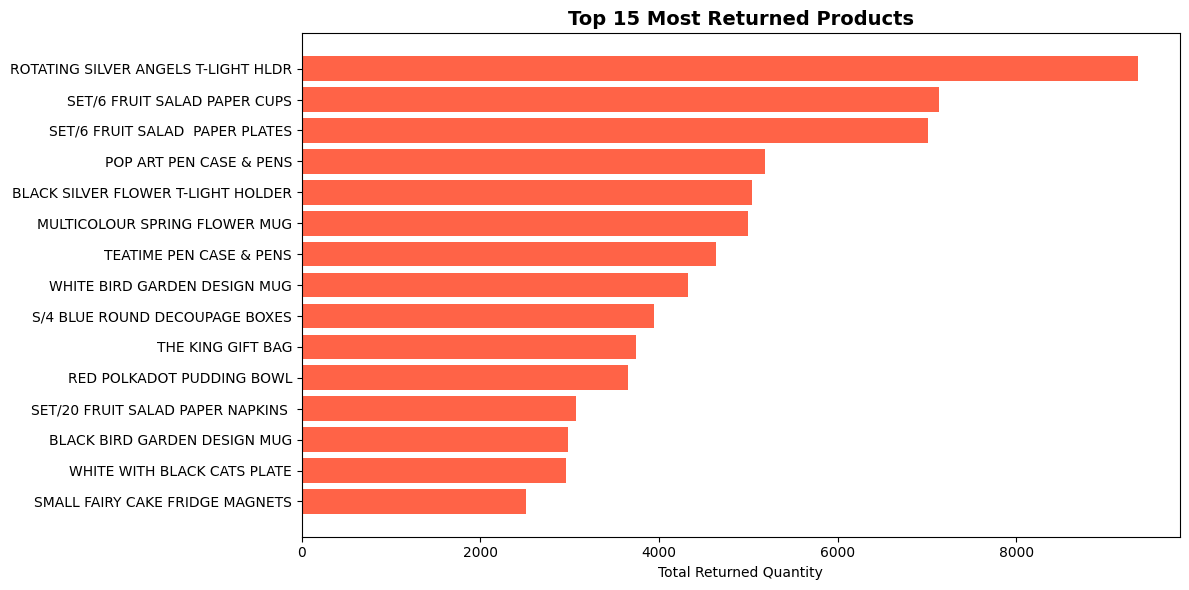

In [33]:
plt.figure(figsize=(12,6))
plt.barh(top_returns["Description"],
         top_returns["ReturnQty"],
         color = "tomato")
plt.gca().invert_yaxis()
plt.title("Top 15 Most Returned Products",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Total Returned Quantity")
plt.tight_layout()
plt.show()

The top sellers by quantity are mostly small, low-cost gift and novelty items like cake cases, gift bags, decorative holders. These move in high volumes but that doesn't always translate to revenue. The White Hanging Heart T-Light Holder tops both lists though, which means it sells a lot and earns a lot, a genuinely strong product.

The Regency Cakestand 3 Tier sits at number two by revenue despite not appearing in the top quantity list at all. That's the kind of product worth protecting in any retention strategy.


The Rotating Silver Angels T-Light Holder has 9,363 units returned, which is significant. A few products show up consistently in the returns list and that's like a product quality signal.

### **Time-Based Patterns**

In [34]:
eda_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12


In [35]:
# Orders by days of week and hour
eda_df["DayOfWeek"] = eda_df["InvoiceDate"].dt.day_name()
eda_df["Hour"] = eda_df["InvoiceDate"].dt.hour

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

orders_by_day = (eda_df.groupby("DayOfWeek")["Invoice"]
                 .nunique()
                 .reindex(day_order)
                 .reset_index())
orders_by_day

,DayOfWeek,Invoice
0,Monday,3586
1,Tuesday,4526
2,Wednesday,4194
3,Thursday,5025
4,Friday,3308
5,Saturday,30
6,Sunday,2916


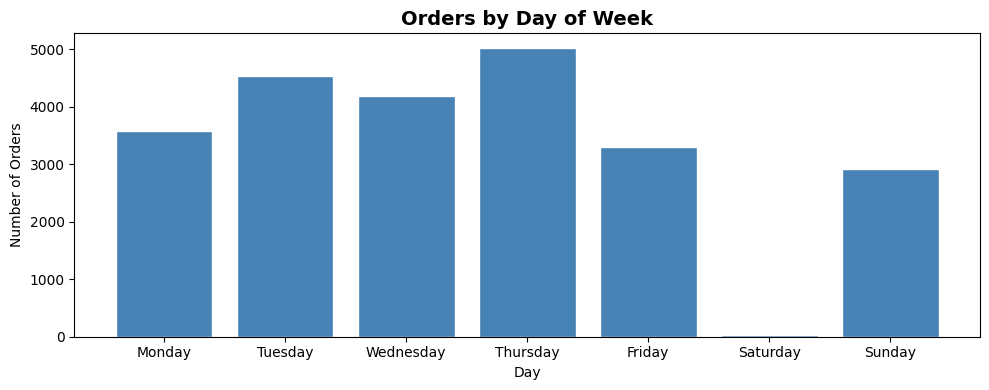

In [36]:
plt.figure(figsize=(10,4))
plt.bar(orders_by_day["DayOfWeek"],
        orders_by_day["Invoice"],
        color="steelblue",
        edgecolor="white")
plt.title("Orders by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [37]:
# Orders by hour
orders_by_hours = (eda_df.groupby("Hour")["Invoice"]
                   .nunique()
                   .reset_index())
orders_by_hours

,Hour,Invoice
0,7,79
1,8,538
2,9,1448
3,10,2682
4,11,2978
5,12,3703
6,13,3421
7,14,2828
8,15,2468
9,16,1665


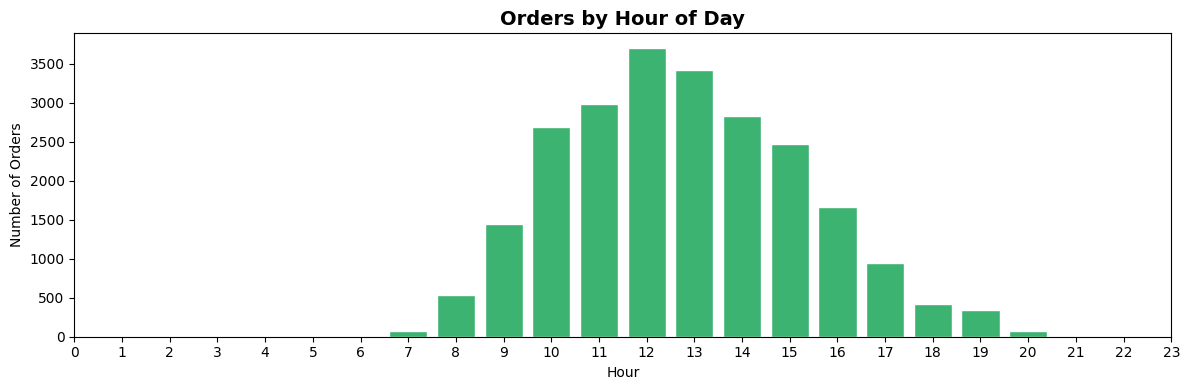

In [38]:
plt.figure(figsize=(12, 4))
plt.bar(orders_by_hours["Hour"],
        orders_by_hours["Invoice"],
        color = "mediumseagreen",
        edgecolor="white")
plt.title("Orders by Hour of Day",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

Thursday is the busiest day with 5,025 invoices, and the weekend drops off sharply. Saturday and Sunday combined barely match a single weekday. Retail consumers shop on weekends, but small business buyers tend to place orders during the work week.


Order activity by hour peaks around 12pm and stays busy through mid-afternoon, then tails off after 5pm. Most purchasing happens during late morning to early afternoon, which has implications for when to send retention emails and winback campaigns.

### **Cohort Retention Heatmap**

In [39]:
eda_df["InvoiceMonth"] = eda_df["InvoiceDate"].dt.to_period("M")

cohort_data = eda_df.groupby("Customer ID")["InvoiceMonth"].min().reset_index()
cohort_data.columns = ["Customer ID", "CohortMonth"]
cohort_data

,Customer ID,CohortMonth
0,12346,2009-12
1,12347,2010-10
2,12348,2010-09
3,12349,2009-12
4,12351,2010-11
...,...,...
4376,18283,2010-02
4377,18284,2010-10
4378,18285,2010-02
4379,18286,2009-12


In [40]:
cohort_df = eda_df.merge(cohort_data, on="Customer ID")
cohort_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth,DayOfWeek,Hour,InvoiceMonth,CohortMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,Tuesday,7,2009-12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7,2009-12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7,2009-12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,Tuesday,7,2009-12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,Tuesday,7,2009-12,2009-12


In [41]:
cohort_df["CohortIndex"] = (
    (cohort_df["InvoiceMonth"].dt.year - cohort_df["CohortMonth"].dt.year) * 12 +
    (cohort_df["InvoiceMonth"].dt.month - cohort_df["CohortMonth"].dt.month)
)
cohort_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth,DayOfWeek,Hour,InvoiceMonth,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,Tuesday,7,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,Tuesday,7,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,Tuesday,7,2009-12,2009-12,0


In [42]:
# Cohort table
cohort_counts = (cohort_df.groupby(["CohortIndex", "CohortMonth"])["Customer ID"]
                 .nunique()
                 .unstack(fill_value=0))
cohort_counts

CohortMonth,2009-12,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,2010-08,2010-09,2010-10,2010-11,2010-12
CohortIndex,,,,,,,,,,,,,
0,1045,394,361,436,291,254,269,183,158,242,379,322,47
1,392,86,109,95,67,49,58,38,39,73,112,38,0
2,358,119,82,113,58,45,53,37,50,63,39,0,0
3,447,120,110,103,47,49,55,52,51,28,0,0,0
4,410,110,93,100,54,48,62,55,20,0,0,0,0
5,408,115,76,87,67,66,76,21,0,0,0,0,0
6,408,105,79,105,79,56,20,0,0,0,0,0,0
7,374,91,103,130,76,22,0,0,0,0,0,0,0
8,355,114,100,126,22,0,0,0,0,0,0,0,0


The cohort heatmap tracks how many customers from each monthly acquisition group came back in subsequent months. The December 2009 cohort is the largest starting group with 1,045 customers, and you can see retention dropping off quickly after the first month, which is normal, but the rate matters.


Most cohorts lose the bulk of their customers within the first two to three months. After that, whoever is still purchasing tends to stick around, but the window to win someone back is short. The later 2010 cohorts are smaller and have less history, so we can't draw much from those yet.


In [43]:
# Retention rate
cohort_size = cohort_counts.iloc[:,0]
retention_rate = cohort_counts.divide(cohort_size, axis=0).round(3) * 100

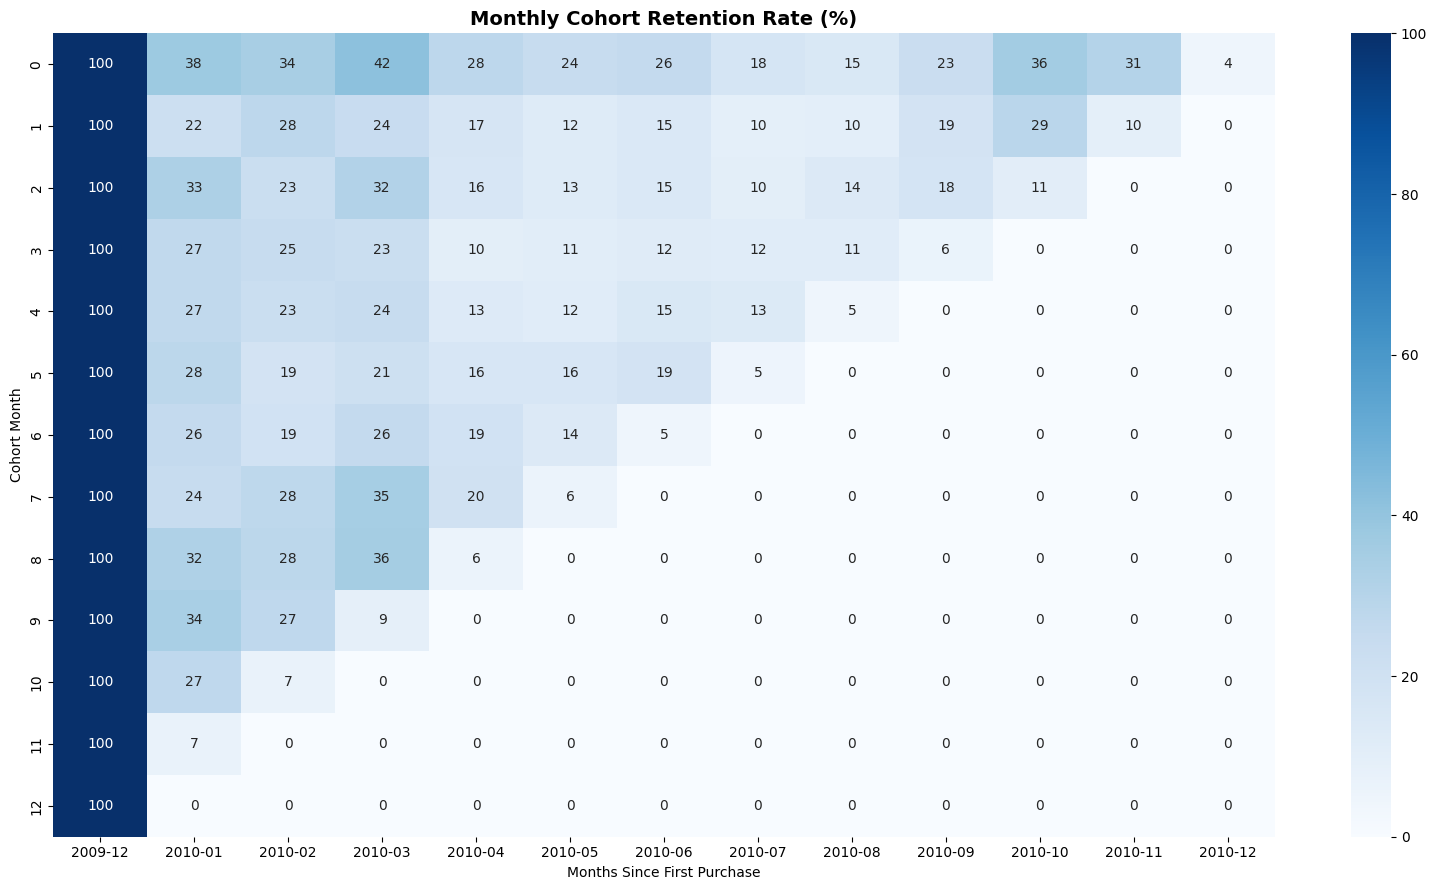

In [44]:
# Retention Rate Plot
plt.figure(figsize=(16,9))
sns.heatmap(
    retention_rate.iloc[:, :13],
    annot=True,
    fmt=".0f",
    cmap="Blues"
)
plt.title("Monthly Cohort Retention Rate (%)", fontsize=14, fontweight="bold")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

### **RFM Distribution**

In [45]:
snapshot_date = eda_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = eda_df.groupby("Customer ID").agg(
    Recency = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("Invoice", "nunique"),
    Monetary = ("Revenue", "sum")
).reset_index()

rfm

,Customer ID,Recency,Frequency,Monetary
0,12346,67,15,-51.74
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,4,2646.99
4,12351,11,1,300.93
...,...,...,...,...
4376,18283,18,6,619.37
4377,18284,65,2,436.68
4378,18285,296,1,427.00
4379,18286,112,3,1188.43


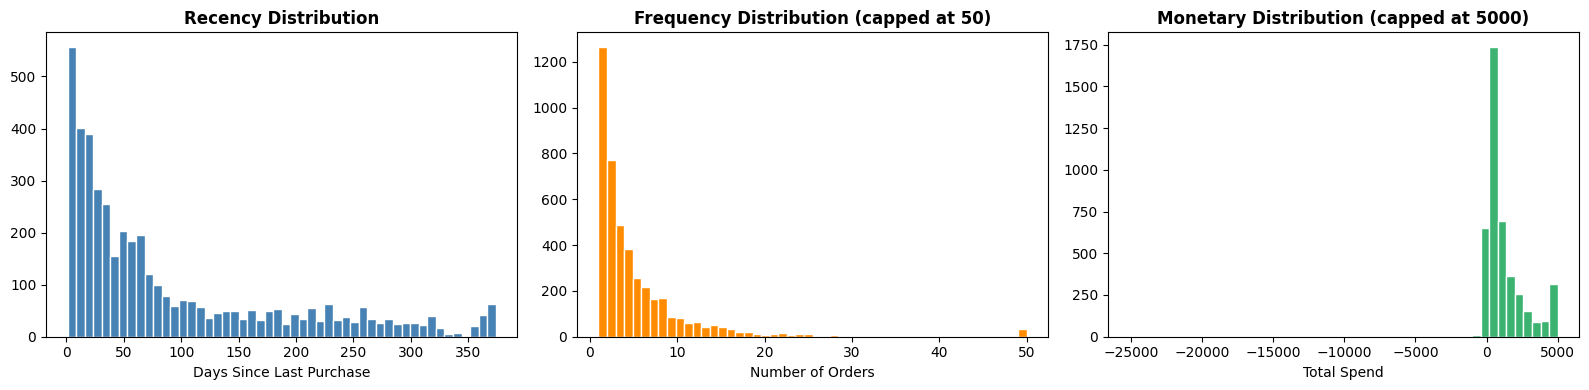

In [46]:
# Plot rfm
fig, axes = plt.subplots(1, 3, figsize=(16,4))
axes[0].hist(rfm["Recency"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Recency Distribution", fontweight="bold")
axes[0].set_xlabel("Days Since Last Purchase")

axes[1].hist(rfm["Frequency"].clip(upper=50), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Frequency Distribution (capped at 50)", fontweight="bold")
axes[1].set_xlabel("Number of Orders")

axes[2].hist(rfm["Monetary"].clip(upper=5000), bins=50, color="mediumseagreen", edgecolor="white")
axes[2].set_title("Monetary Distribution (capped at 5000)", fontweight="bold")
axes[2].set_xlabel("Total Spend")

plt.tight_layout()
plt.show()

The recency distribution is right-skewed. A large chunk of customers last purchased within the first 30 days, then it spreads out gradually across the year. That early spike is good, it means a large portion of the base is still active, but the long tail tells us there are plenty of customers who haven't bought in months.


Frequency is heavily concentrated at 1 to 3 orders. Most customers just don't buy that often, which tracks with the 29% one-time buyer. A small number of customers are placing 20, 30, even 50+ orders and those are almost certainly wholesale or B2B accounts.


The monetary distribution has a negative tail. Those are the returns-heavy customers. On the right side, most customers sit under £1,000 total, with a small group going much higher.